In [38]:
import geopandas as gpd
import xarray as xr
import numpy as np
import rioxarray as rxr
import os
from math import e
import matplotlib.pyplot as plt
import pandas as pd

In [39]:
# Import 47 basin dNBR data and the 727 basin subset with needed RI values.

basin_47 = pd.read_csv(r'/Volumes/PhD/imagery/masters/output/hyper_compare/all_basins_dnbr.csv')

basin_727 = gpd.read_file(r'/Volumes/PhD/imagery/masters/ROC/M1_CT_ROC.shp')
basin_727

,BASIN_ID,Shape_Leng,Shape_Area,Segment_ID,Acc_Cl,Perim_Buff,InsidePeri,OutsidePer,Fire_ID,Fire_Segme,...,distance_t,RI_index,RI,Mean_dNBR,Med_dNBR,PF_dNBR,M1P_Mean,M1P_Med,M1p_PF,geometry
0,17499,7120.0,1.429800e+06,17499,1.0,10,100,0,thm2017,thm2017_17499,...,2055.346175,23,5.08,0.471854,0.477169,0.459052,0.449618,0.454098,0.438860,"POLYGON ((295619.84 3816329.559, 295619.84 381..."
1,3115,1120.0,4.180000e+04,3115,1.0,10,100,10,thm2017,thm2017_3115,...,1595.604025,29,7.11,0.072363,0.014718,-0.019005,0.148129,0.116710,0.101142,"MULTIPOLYGON (((298029.84 3825079.559, 298029...."
2,3589,4020.0,4.313000e+05,3589,1.0,10,100,0,thm2017,thm2017_3589,...,1881.463927,29,7.11,0.216498,0.051373,-0.020064,0.301476,0.164258,0.122691,"POLYGON ((297059.84 3824619.559, 297069.84 382..."
3,5683,4420.0,5.659000e+05,5683,1.0,10,101,12,thm2017,thm2017_5683,...,1702.372795,21,12.95,0.692429,0.702799,0.724929,0.999180,0.999251,0.999382,"POLYGON ((283709.84 3822919.559, 283689.84 382..."
4,5920,16620.0,7.486600e+06,5920,1.0,10,100,0,thm2017,thm2017_5920,...,1525.053372,37,6.10,0.605956,0.651802,0.753237,0.848432,0.870989,0.910869,"POLYGON ((303389.84 3819559.559, 303389.84 381..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732,15065,1720.0,9.550000e+04,15065,1.0,10,100,0,thm2017,thm2017_15065,...,1173.707451,10,9.14,0.164376,0.111513,0.055359,0.313190,0.248063,0.189564,"POLYGON ((289119.84 3817119.559, 289079.84 381..."
733,35852,2080.0,8.360000e+04,35852,1.0,10,101,12,thm2017,thm2017_35852,...,2151.287445,25,7.37,0.284851,0.279801,0.261897,0.473049,0.466838,0.444912,"MULTIPOLYGON (((278059.84 3804989.559, 278069...."
734,36553,1460.0,4.570000e+04,36553,1.0,10,100,11,thm2017,thm2017_36553,...,1675.063365,25,7.37,0.348485,0.339397,0.331989,0.468316,0.457159,0.448097,"MULTIPOLYGON (((277049.84 3804469.559, 277049...."
735,36955,2380.0,1.098000e+05,36955,1.0,10,100,11,thm2017,thm2017_36955,...,1352.291607,25,7.37,0.208930,0.202108,0.175856,0.281668,0.274903,0.249830,"POLYGON ((277699.84 3804059.559, 277689.84 380..."


33


<Axes: >

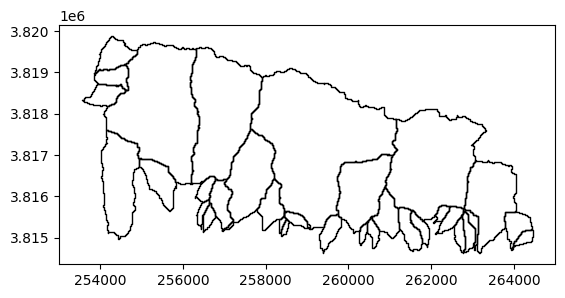

In [40]:
# subset the 747 to the 47 basins with dNBR values, plot subset with basin boundary lines
basin_727_sub = basin_727[basin_727['BASIN_ID'].isin(basin_47['BASIN_ID'])]
print(len(basin_727_sub))
basin_727_sub.plot(edgecolor='black', facecolor='none')


In [42]:
# Subset 47 to match the 727 subset
basin_47_sub = basin_47[basin_47['BASIN_ID'].isin(basin_727_sub['BASIN_ID'])]
print(len(basin_47_sub))
print(basin_47_sub.columns)

33
Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'HMean_dNBR', 'HMed_dNBR',
       'HPF_dNBR', 'iHMean_dNB', 'iHMed_dNBR', 'iHPF_dNBR', 'geometry', 'MQ1',
       'HQ1', 'OHQ1'],
      dtype='object')


In [43]:
# Modify the ID names for IH to OH
basin_47_sub.rename(columns={'Mean_dNBR': 'M1M_dNBR', 
                              'Med_dNBR': 'M1Md_dNBR',
                              'PF_dNBR': 'M1PF_dNBR',
                              'MQ1': 'M1Q1_dNBR',
                              'HMean_dNBR': 'HM1M_dNBR',
                              'HMed_dNBR': 'HM1Md_dNBR',
                              'HPF_dNBR': 'HM1PF_dNBR',
                              'HQ1': 'HM1Q1_dNBR',
                              'iHMean_dNB': 'OHM1M_dNBR',
                              'iHMed_dNBR': 'OHM1Md_dNBR',
                              'iHPF_dNBR': 'OHM1PF_dNBR',
                              'OHQ1': 'OHM1Q1_dNBR'
                              }, inplace=True)
 


/var/folders/mm/sjj0b1k91z39pkxfzn0rj_1h0000gn/T/ipykernel_54992/667340927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  basin_47_sub.rename(columns={'Mean_dNBR': 'M1M_dNBR',


In [44]:
basin_47_sub

,BASIN_ID,Shape_Leng,Shape_Area,Segment_ID,Acc_Cl,Perim_Buff,InsidePeri,OutsidePer,Fire_ID,Fire_Segme,...,HM1M_dNBR,HM1Md_dNBR,HM1PF_dNBR,OHM1M_dNBR,OHM1Md_dNBR,OHM1PF_dNBR,geometry,M1Q1_dNBR,HM1Q1_dNBR,OHM1Q1_dNBR
0,12042,3940.0,4.806000e+05,12042,1.0,10,0,0,thm2017,thm2017_12042,...,0.262956,0.136330,0.062367,0.258852,0.109183,0.061562,MULTIPOLYGON (((253869.8397442837 3818979.5589...,0.035669,0.032521,-0.012101
1,12057,3240.0,3.219000e+05,12057,1.0,10,100,11,thm2017,thm2017_12057,...,0.579999,0.626966,0.684872,0.606183,0.689793,0.683618,POLYGON ((254639.83974427744 3818559.558904074...,0.312838,0.388735,0.374259
8,13281,3400.0,3.442000e+05,13281,1.0,10,0,0,thm2017,thm2017_13281,...,0.298768,0.158059,0.095617,0.291774,0.163046,0.096075,POLYGON ((254179.83974428015 3818189.558904070...,0.039378,0.067986,0.013146
9,17346,12820.0,5.057100e+06,17346,1.0,10,100,0,thm2017,thm2017_17346,...,0.559421,0.652311,0.730773,0.562744,0.678311,0.729730,POLYGON ((255819.83974427122 3816339.558904038...,0.274913,0.314444,0.254773
10,17347,11360.0,3.885200e+06,17347,1.0,10,100,0,thm2017,thm2017_17347,...,0.719154,0.751083,0.760993,0.757949,0.803069,0.760789,POLYGON ((256189.83974426758 3816319.558904037...,0.543211,0.627597,0.639774
11,17987,2320.0,1.683000e+05,17987,1.0,10,101,12,thm2017,thm2017_17987,...,0.703093,0.712471,0.711777,0.729358,0.759727,0.712492,MULTIPOLYGON (((256289.83974426758 3815979.558...,0.552817,0.650307,0.668135
12,19165,11680.0,4.431700e+06,19165,1.0,10,100,0,thm2017,thm2017_19165,...,0.527609,0.538886,0.575769,0.537904,0.560659,0.575276,MULTIPOLYGON (((262629.8397442352 3817949.5589...,0.370157,0.395765,0.365453
13,19167,1800.0,8.440000e+04,19167,1.0,10,100,0,thm2017,thm2017_19167,...,0.528139,0.553134,0.576768,0.555557,0.583779,0.576546,MULTIPOLYGON (((262049.83974423897 3815359.558...,0.449128,0.466845,0.487578
14,19381,2100.0,1.342000e+05,19381,1.0,10,100,0,thm2017,thm2017_19381,...,0.588130,0.605765,0.628600,0.628596,0.633624,0.629051,MULTIPOLYGON (((259049.839744257 3815229.55890...,0.468187,0.527390,0.534030
15,19384,16440.0,7.626000e+06,19384,1.0,10,100,0,thm2017,thm2017_19384,...,0.623141,0.643520,0.663306,0.631775,0.665531,0.662113,"POLYGON ((258989.8397442525 3815399.558904024,...",0.444209,0.513701,0.493099


In [45]:
basin_727_sub.columns

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'geometry'],
      dtype='object')

In [46]:
# create new dataframe with only the dNBR values and the BASIN_ID
newBdf = basin_47_sub[['BASIN_ID', 'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR', 'HM1M_dNBR', 'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR', 'OHM1Md_dNBR', 'OHM1PF_dNBR', 'OHM1Q1_dNBR']]
newBdf

,BASIN_ID,M1M_dNBR,M1Md_dNBR,M1PF_dNBR,M1Q1_dNBR,HM1M_dNBR,HM1Md_dNBR,HM1PF_dNBR,HM1Q1_dNBR,OHM1M_dNBR,OHM1Md_dNBR,OHM1PF_dNBR,OHM1Q1_dNBR
0,12042,0.216600,0.117223,0.049315,0.035669,0.262956,0.136330,0.062367,0.032521,0.258852,0.109183,0.061562,-0.012101
1,12057,0.479306,0.533185,0.599167,0.312838,0.579999,0.626966,0.684872,0.388735,0.606183,0.689793,0.683618,0.374259
8,13281,0.241379,0.111679,0.055610,0.039378,0.298768,0.158059,0.095617,0.067986,0.291774,0.163046,0.096075,0.013146
9,17346,0.485873,0.580163,0.633644,0.274913,0.559421,0.652311,0.730773,0.314444,0.562744,0.678311,0.729730,0.254773
10,17347,0.618329,0.645576,0.659255,0.543211,0.719154,0.751083,0.760993,0.627597,0.757949,0.803069,0.760789,0.639774
11,17987,0.599755,0.613116,0.622772,0.552817,0.703093,0.712471,0.711777,0.650307,0.729358,0.759727,0.712492,0.668135
12,19165,0.476881,0.499206,0.546480,0.370157,0.527609,0.538886,0.575769,0.395765,0.537904,0.560659,0.575276,0.365453
13,19167,0.491453,0.514423,0.533206,0.449128,0.528139,0.553134,0.576768,0.466845,0.555557,0.583779,0.576546,0.487578
14,19381,0.527848,0.533183,0.532975,0.468187,0.588130,0.605765,0.628600,0.527390,0.628596,0.633624,0.629051,0.534030
15,19384,0.543026,0.565196,0.604142,0.444209,0.623141,0.643520,0.663306,0.513701,0.631775,0.665531,0.662113,0.493099


In [48]:
# Merge the newBdf with the basin_727_sub to get the RI values in the same dataframe as the dNBR values
merged_df = pd.merge(basin_727_sub, newBdf, on='BASIN_ID')
merged_df
print(merged_df.columns)

Index(['BASIN_ID', 'Shape_Leng', 'Shape_Area', 'Segment_ID', 'Acc_Cl',
       'Perim_Buff', 'InsidePeri', 'OutsidePer', 'Fire_ID', 'Fire_Segme',
       'L_X1', 'L_X2', 'L_X3', 'V_X1', 'V_X2', 'Shape_Le_1', 'R', 'V_X3', 'X',
       'ExpX', 'P', 'PCl', 'PCl_Legend', 'LnV', 'Volume', 'VolMin', 'VolMax',
       'VolCl', 'VolCl_Lege', 'CombHaz', 'CombHazCl', 'CombHazCl_', 'area',
       'Field', 'ROC', 'nearest_st', 'distance_t', 'RI_index', 'RI',
       'Mean_dNBR', 'Med_dNBR', 'PF_dNBR', 'M1P_Mean', 'M1P_Med', 'M1p_PF',
       'geometry', 'M1M_dNBR', 'M1Md_dNBR', 'M1PF_dNBR', 'M1Q1_dNBR',
       'HM1M_dNBR', 'HM1Md_dNBR', 'HM1PF_dNBR', 'HM1Q1_dNBR', 'OHM1M_dNBR',
       'OHM1Md_dNBR', 'OHM1PF_dNBR', 'OHM1Q1_dNBR'],
      dtype='object')


In [49]:
#save the new 47 subset with RI values as a shapefile
merged_df.to_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_dNBR_RI.shp', driver='ESRI Shapefile')

/var/folders/mm/sjj0b1k91z39pkxfzn0rj_1h0000gn/T/ipykernel_54992/2347912164.py:2: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  merged_df.to_file(r'/Volumes/PhD/imagery/masters/output/hyper_compare/landslides_edits/MontecitoBasins_dNBR_RI.shp', driver='ESRI Shapefile')
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1Md_dNBR' to 'OHM1Md_dNB'
  ogr_write(
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1PF_dNBR' to 'OHM1PF_dNB'
  ogr_write(
/Users/samueltaylor/Documents/GitHub/PHA_burn_severity/.venv/lib/python3.9/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'OHM1Q1_dNBR' to 'OHM1Q1_dNB'
  ogr_write(
